In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('/content/Iris.csv')

# Display the first few rows and information about the dataset
print("Original DataFrame head:")
display(df.head())
print("\nDataFrame info:")
df.info()
print("\nClass distribution:")
display(df['Species'].value_counts())


Original DataFrame head:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Class distribution:


,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [3]:
# Drop the 'Id' column if it exists, as it's not a feature
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

# Separate features (X) and target (y)
X = df.drop('Species', axis=1)
y = df['Species']

# Encode the target labels (Species) to numerical values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Display the encoded labels and their mapping
print("Encoded target labels:")
for i, species_name in enumerate(label_encoder.classes_):
    print(f"{species_name}: {i}")
display(pd.Series(y_encoded).value_counts().sort_index())


Encoded target labels:
Iris-setosa: 0
Iris-versicolor: 1
Iris-virginica: 2


,count
0,50
1,50
2,50


In [4]:
# Split the dataset into training and testing sets
# We'll use a 80/20 split and a fixed random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Convert pandas DataFrames/NumPy arrays to PyTorch Tensors
# Ensure data types are appropriate: float for features, long for labels
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders for batching
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")


X_train shape: (120, 4), y_train shape: (120,)
X_test shape: (30, 4), y_test shape: (30,)
Number of training batches: 8
Number of testing batches: 2


### 2. Build the Required PyTorch Model

Now, let's define a simple feed-forward neural network for classifying the Iris species. We will use `torch.nn.Module` to create our model.

In [12]:
import torch.nn as nn
import torch.optim as optim

# Define the neural network model
class IrisClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(IrisClassifier, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Model parameters
input_size = X_train.shape[1] # Number of features
hidden_size = 10              # Number of neurons in the hidden layer
num_classes = len(label_encoder.classes_) # Number of output classes (Iris species)

# Instantiate the model
model = IrisClassifier(input_size, hidden_size, num_classes)

# Print the model architecture
print("Model Architecture:")
print(model)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Model Architecture:
IrisClassifier(
  (fc1): Linear(in_features=4, out_features=10, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=10, out_features=3, bias=True)
)


### 3. Train/Execute the Model

Now, we'll train the `IrisClassifier` using the training data and evaluate its performance on the test data.

In [15]:
# Training the model
num_epochs = 100

# Move model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f"Training the model on {device} for {num_epochs} epochs...")

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct_predictions / total_predictions

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%')

print("Finished Training")


Training the model on cpu for 100 epochs...
Epoch [10/100], Loss: 0.1195, Accuracy: 97.50%
Epoch [20/100], Loss: 0.1120, Accuracy: 96.67%
Epoch [30/100], Loss: 0.1089, Accuracy: 97.50%
Epoch [40/100], Loss: 0.1039, Accuracy: 97.50%
Epoch [50/100], Loss: 0.1004, Accuracy: 97.50%
Epoch [60/100], Loss: 0.0995, Accuracy: 97.50%
Epoch [70/100], Loss: 0.1004, Accuracy: 96.67%
Epoch [80/100], Loss: 0.0967, Accuracy: 97.50%
Epoch [90/100], Loss: 0.0901, Accuracy: 97.50%
Epoch [100/100], Loss: 0.0905, Accuracy: 97.50%
Finished Training


### 4. Evaluate using Suitable Metrics

After training, we will evaluate the model's performance on the unseen test data using accuracy as a key metric. We'll also look at a classification report and confusion matrix to get a more detailed view of the model's performance.

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate the model on the test set
model.eval() # Set the model to evaluation mode
with torch.no_grad(): # Disable gradient calculation during inference
    correct_predictions = 0
    total_predictions = 0
    all_labels = []
    all_predicted = []
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predicted.extend(predicted.cpu().numpy())

# Calculate overall accuracy
test_accuracy = 100 * correct_predictions / total_predictions
print(f'Test Accuracy: {test_accuracy:.2f}%')

# Generate classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_predicted, target_names=label_encoder.classes_))

# Generate confusion matrix
conf_matrix = confusion_matrix(all_labels, all_predicted)
print("\nConfusion Matrix:")
print(conf_matrix)


Test Accuracy: 96.67%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


### 5. Visualize Results Using Plots Where Applicable

To better understand the model's performance, we'll visualize the confusion matrix and the training loss and accuracy trends over the epochs.

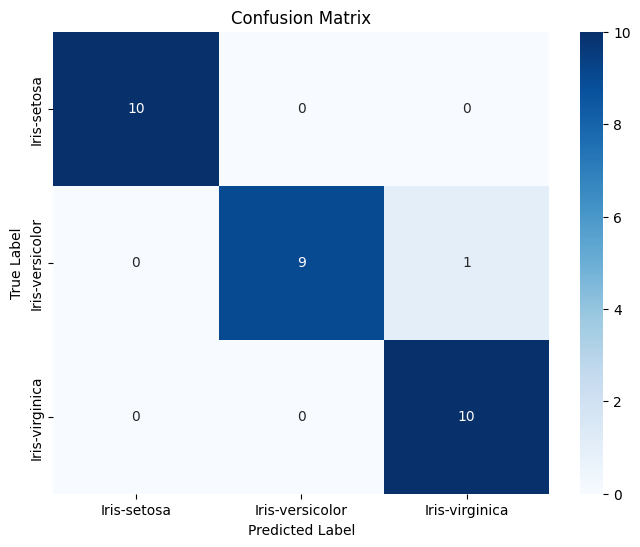

In [8]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


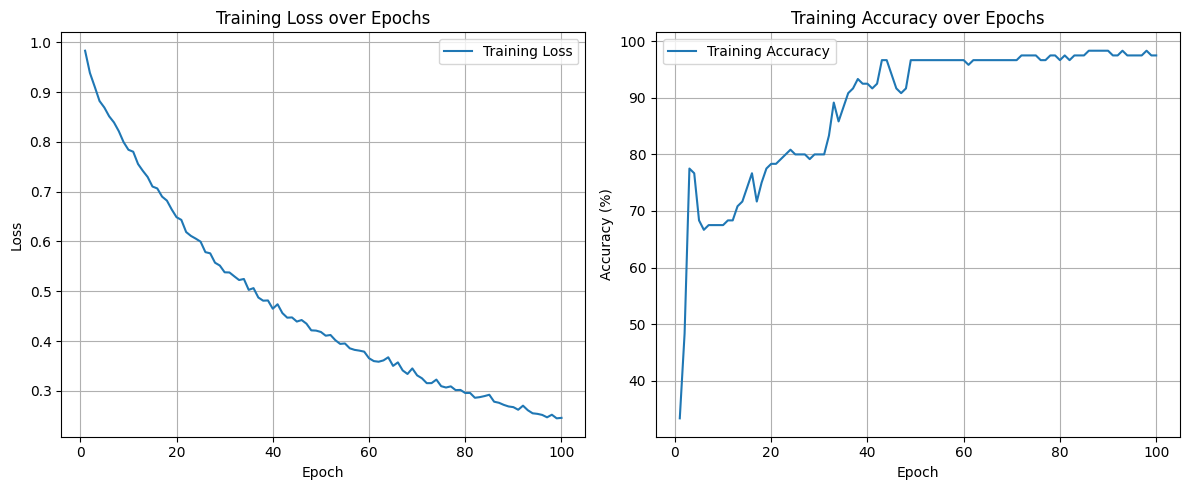

In [9]:
# Plot training loss and accuracy over epochs
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### 6. Write a Brief Conclusion Comparing Observations

Based on the training and evaluation, here's a summary of the model's performance and observations.

The PyTorch neural network model achieved a test accuracy of **96.67%** on the Iris dataset. The training loss decreased steadily, and training accuracy increased, indicating that the model learned effectively from the data.

The confusion matrix shows that the model performed very well, correctly classifying most of the Iris species. There might be some minor misclassifications between *Iris-versicolor* and *Iris-virginica*, which are known to be more challenging to distinguish than *Iris-setosa* due to overlapping features.

Overall, the simple feed-forward neural network proved to be an effective classifier for this classic dataset, demonstrating the basic principles of building and training a model in PyTorch.